# Dataset Preparation

- input: curated briefsummary
- output: pd.series of ase objects pr pymatgen objects


In [1]:
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
import os
import pandas as pd
from BopFoxFeaturizer.Featurizer import Featurizer
from Tools.DatasetTools.Tools import need_to_update
from Tools.DatasetTools.SublatticeSorter import *
from pymatgen.io.ase import AseAtomsAdaptor

# options 

In [2]:
dataset = 'Cr-Co-W'
case='POSCAR-initial' #, 'POSCAR-relaxed']
rescale_by_atoms=True #, False]
subcase = 'rescaled' # ,  'noscaled' ] 
Force= True
CuratedBS = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')

In [3]:
components = dataset.replace('-','')

In [4]:
BS = pd.read_pickle(CuratedBS)

In [5]:
Features = Featurizer(BS)

chech that the chemistry resetting is correct!

# Sort Poscar files

In [6]:
searchs = 'POSCAR.initial'
files = get_file_paths(dataset, searchs)
atomsobjectslocation = os.path.join(dataset,'Atomsobjects')
sublatticesortersfile = os.path.join(atomsobjectslocation, 'SORTERS.pkl')
sublatticetagfile = os.path.join(atomsobjectslocation, 'SUBLATICETAGS.pkl')

In [7]:
if need_to_update(sublatticesortersfile) or need_to_update(sublatticetagfile):
    SORTERS, SUBLATICETAGS = get_all_sorters_and_tags(dataset, files)
    SORTERS.to_pickle(sublatticesortersfile)
    SUBLATICETAGS.to_pickle(sublatticetagfile)
else:
    SORTERS = pd.read_pickle(sublatticesortersfile)
    SUBLATICETAGS = pd.read_pickle(sublatticetagfile)

# Now I have to pick the atoms objects

In [8]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
database = f'{dataset}/**/{case}'
AtomsFile = os.path.join(atomsobjectslocation,f'{components}-sorted-{case}-{subcase}-AtomsObjects.pkl')

In [9]:
if not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
    Atoms_Objects = pd.read_pickle(AtomsFile)
else:
    Atoms_Objects, CantMake_Atoms_Object = Features.get_atoms_object(database=database,rescale_by_atoms=True, reset_chemistry=True,file_filter = 'sorted')
    Atoms_Objects.to_pickle(AtomsFile)
    Atoms_Objects.dropna(inplace=True)
pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
Pymatgen_Structures = Atoms_Objects.copy()
if not need_to_update(pymatgenfile):
    Pymatgen_Structures = pd.read_pickle(pymatgenfile)
else:
    Pymatgen_Structures = Atoms_Objects['atoms'].apply(AseAtomsAdaptor.get_structure)
    Pymatgen_Structures['file'] = Atoms_Objects['file']
    Pymatgen_Structures.to_pickle(pymatgenfile)

  0%|          | 0/1701 [00:00<?, ?it/s]

In [10]:
Atoms_Objects.atoms.isna().sum()

0

In [11]:
Atoms_Objects.to_pickle(AtomsFile)

In [12]:
accomodatewrap = Atoms_Objects.atoms.map(lambda a: a.wrap(pretty_translation=True))

In [13]:
difference = BS.index.difference(Atoms_Objects.index)

In [14]:
difference

Index(['Co_pv1.bcc.FM', 'Co_pv1.fcc.FM', 'Co_pv15W_sv38.R-AAAABBBBBBB.NM',
       'Co_pv1W_sv52.R-ABBBBBBBBBB.NM', 'Co_pv21W_sv32.R-AAAAABBBBBB.NM',
       'Co_pv27W_sv26.R-AAAAAABBBBB.NM', 'Co_pv30.sigma_Co_pv.FM',
       'Co_pv33W_sv20.R-AAAAAAABBBB.NM', 'Co_pv3W_sv50.R-AABBBBBBBBB.NM',
       'Co_pv45W_sv8.R-AAAAAAAAABB.NM', 'Co_pv47W_sv6.R-AAAAAAAAAAB.NM',
       'Co_pv9W_sv44.R-AAABBBBBBBB.NM', 'Cr_pv1.bcc.FM', 'Cr_pv1.fcc.FM',
       'Cr_pv1W_sv52.R-ABBBBBBBBBB.NM', 'Cr_pv27W_sv26.R-AAAAAABBBBB.NM',
       'Cr_pv39W_sv14.R-AAAAAAAABBB.NM', 'Cr_pv3W_sv50.R-AABBBBBBBBB.NM',
       'Cr_pv45W_sv8.R-AAAAAAAAABB.NM', 'Cr_pv47W_sv6.R-AAAAAAAAAAB.NM'],
      dtype='object')

#  visualization of some structures

In [15]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [16]:
from ase.visualize.plot import plot_atoms

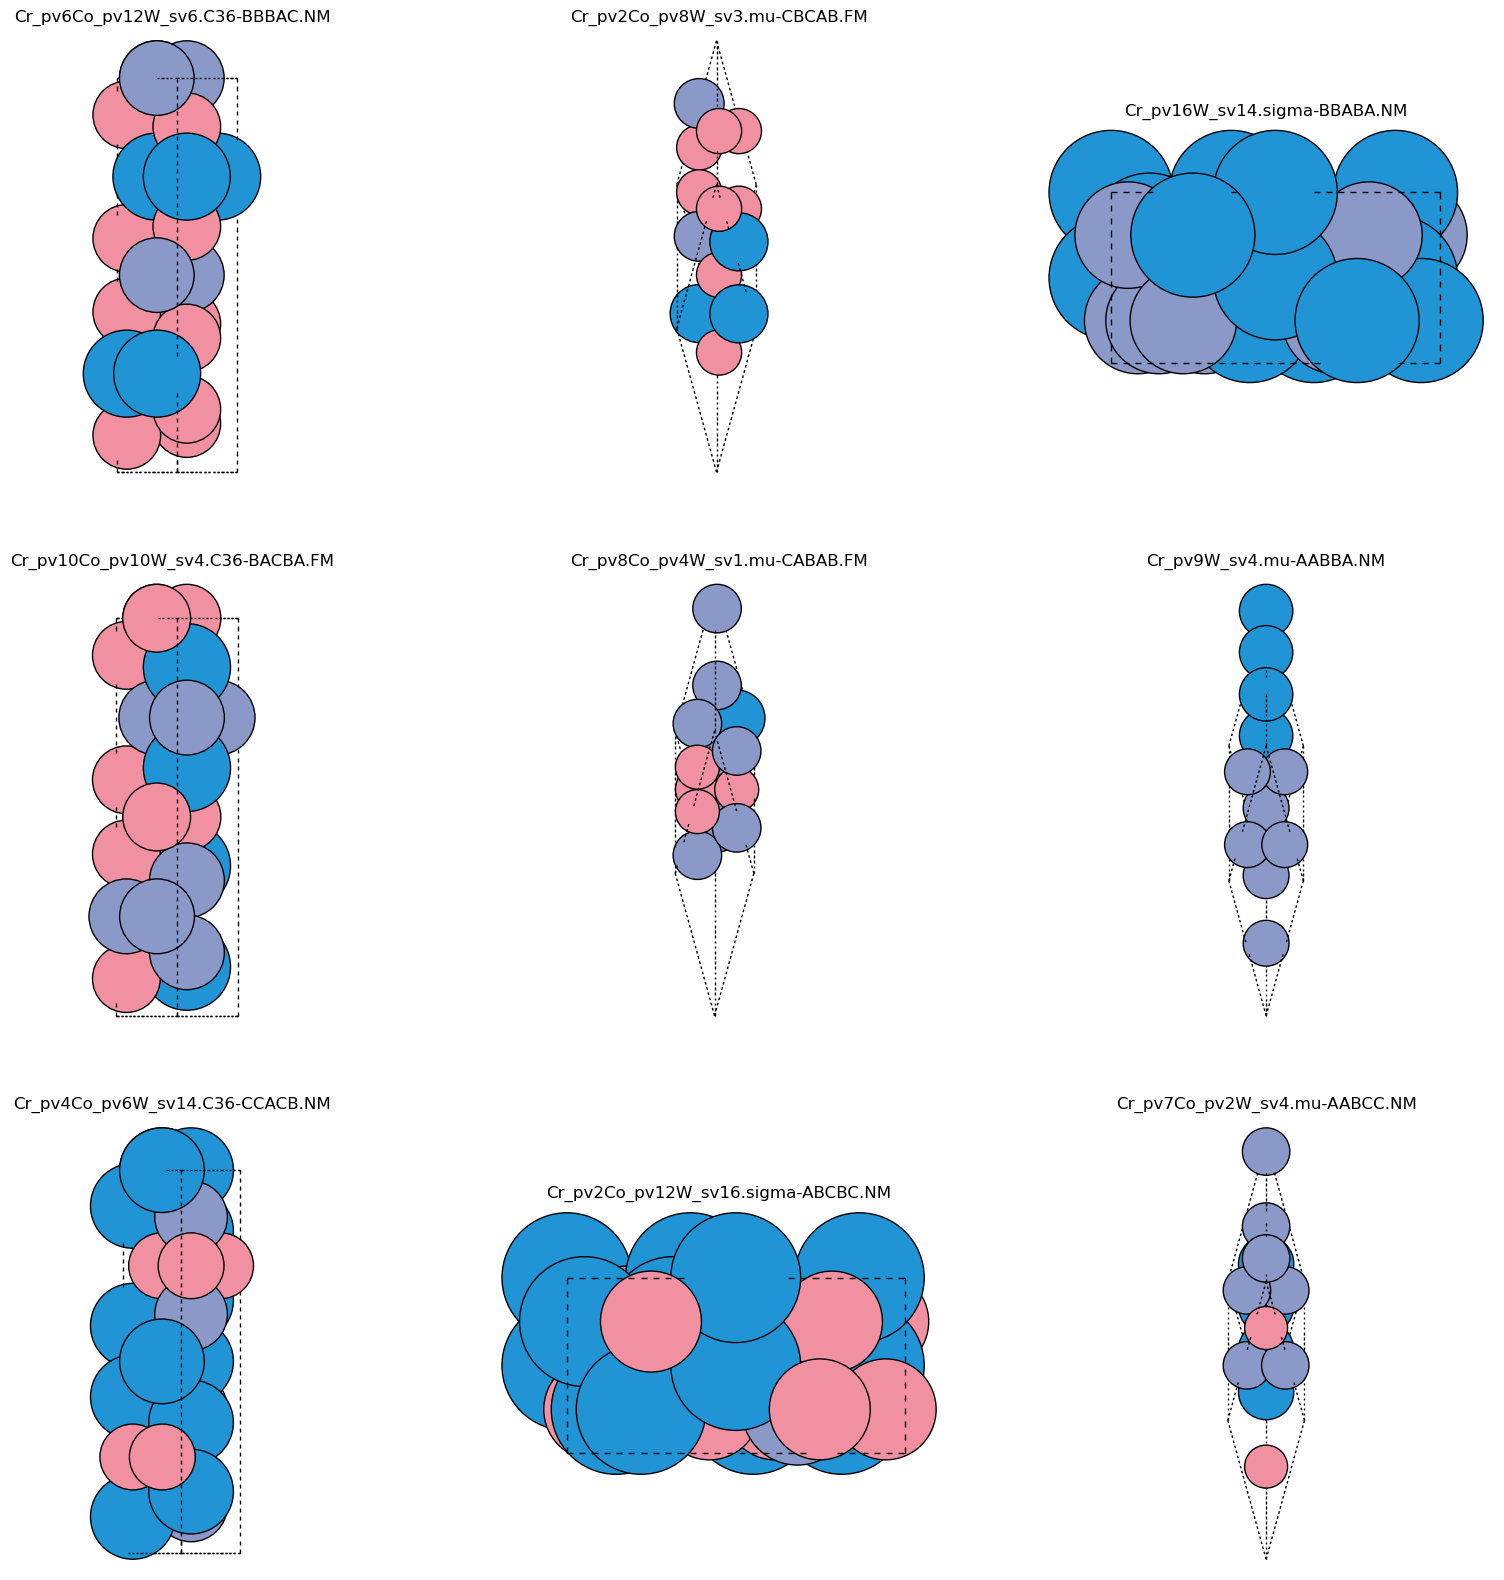

In [17]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [18]:
somesigmas = Atoms_Objects.atoms[Atoms_Objects.index.str.contains('sigma')].sample(n=9)

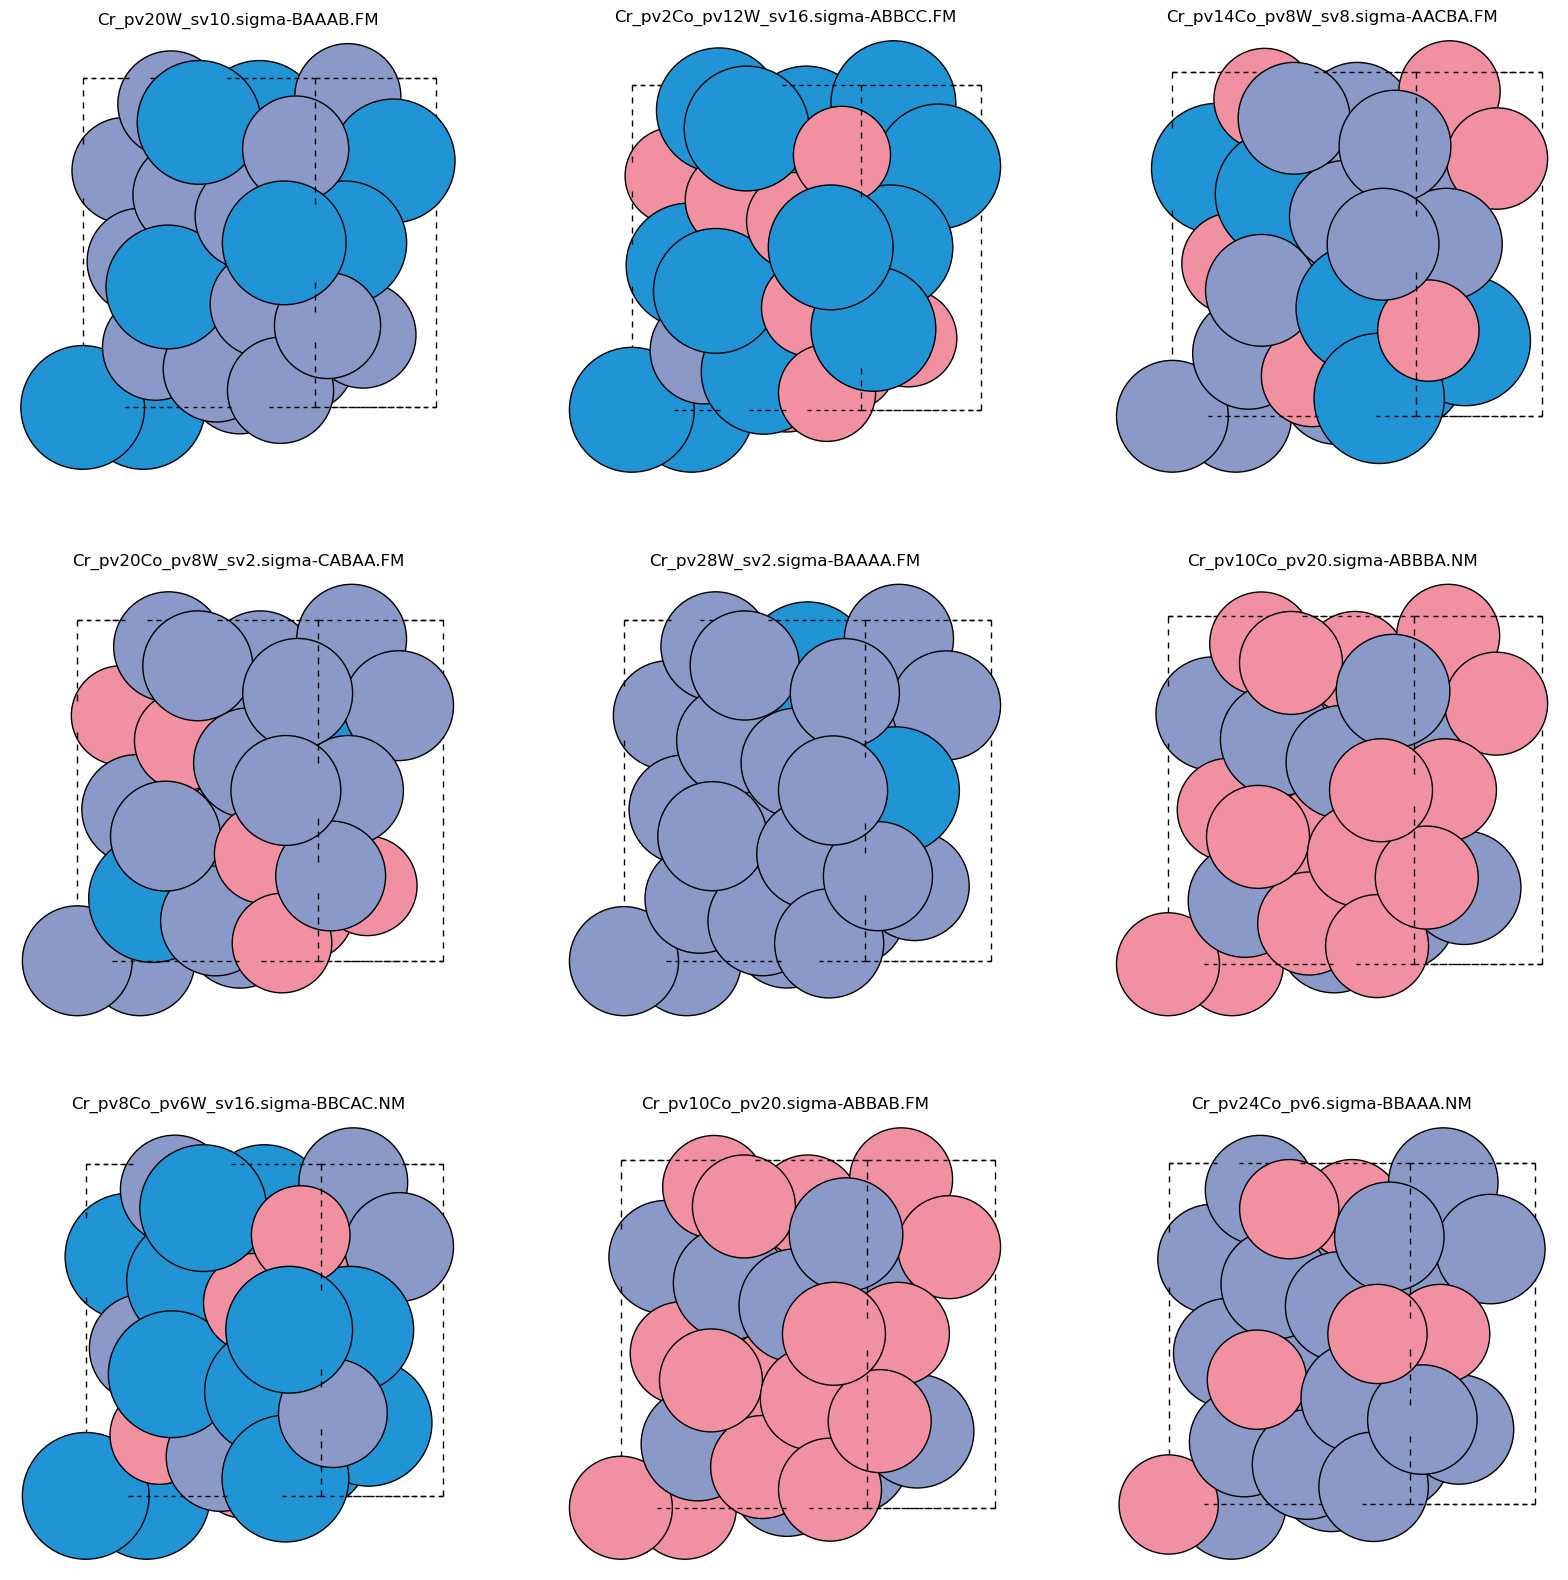

In [19]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.

# Curate Dataset to available structures 

There are still some R structures not available in data but present in briefsummaries

In [20]:
Problems = BS.index.difference(Atoms_Objects.index)

In [21]:
BS.loc[Problems]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Co_pv,Cr_pv,W_sv,Phase
Co_pv1.bcc.FM,bulk bcc.FM,11.091161 A,-6.928152,204.486166 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,1,...,,,1,0,0,1.0,1.000000,0.000000,0.000000,bcc
Co_pv1.fcc.FM,bulk fcc.FM,10.915731 A,-7.011814,206.553175 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,1,...,,,1,0,0,1.0,1.000000,0.000000,0.000000,fcc
Co_pv15W_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.658226 A,-11.126381,287.291148 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,15,38,0,53.0,0.283019,0.000000,0.716981,R
Co_pv1W_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.618107 A,-12.491728,282.261416 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,1,52,0,53.0,0.018868,0.000000,0.981132,R
Co_pv21W_sv32.R-AAAAABBBBBB.NM,bulk R-AAAAABBBBBB,13.841680 A,-10.543402,289.596757 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,21,32,0,53.0,0.396226,0.000000,0.603774,R
Co_pv27W_sv26.R-AAAAAABBBBB.NM,bulk R-AAAAAABBBBB,13.027932 A,-9.939945,291.407504 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,27,26,0,53.0,0.509434,0.000000,0.490566,R
Co_pv30.sigma_Co_pv.FM,bulk sigma_Co_pv.FM,11.085749 A,-6.969542,212.705363 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,1,...,,,30,0,0,30.0,1.000000,0.000000,0.000000,sigma
Co_pv33W_sv20.R-AAAAAAABBBB.NM,bulk R-AAAAAAABBBB,12.415682 A,-9.236755,285.181150 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,33,20,0,53.0,0.622642,0.000000,0.377358,R
Co_pv3W_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,16.339764 A,-12.293662,282.266666 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,3,50,0,53.0,0.056604,0.000000,0.943396,R
Co_pv45W_sv8.R-AAAAAAAAABB.NM,bulk R-AAAAAAAAABB,11.295355 A,-7.737524,264.339213 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,45,8,0,53.0,0.849057,0.000000,0.150943,R


In [22]:
GoodBS = BS.loc[Atoms_Objects.index]

In [23]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Co_pv,Cr_pv,W_sv,Phase
Co_pv6W_sv6.C14-BBA.FM,bulk C14-BBA.FM,13.175678 A,-10.000427,293.907391 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,6,6,0,12.0,0.500000,0.000000,0.500000,C14
Co_pv6W_sv6.C14-BBA.NM,bulk C14-BBA,13.175679 A,-10.000427,293.949578 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,6,6,0,12.0,0.500000,0.000000,0.500000,C14
Cr_pv6W_sv2.D0_19-A3B.FM,bulk D0_19-A3B.FM,13.098145 A,-10.002413,244.993002 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,6,2,0,8.0,0.000000,0.750000,0.250000,hcp
Cr_pv6W_sv2.D0_19-A3B.NM,bulk D0_19-A3B,13.093819 A,-10.002452,248.338396 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,6,2,0,8.0,0.000000,0.750000,0.250000,hcp
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,bulk sigma-CBAAC.FM,13.525828 A,-10.003732,243.415325 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,Co_pv,W_sv,16,4,10,30.0,0.133333,0.533333,0.333333,sigma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,bulk mu-BAAAB.FM,13.271764 A,-9.986312,205.612028 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,10,3,0,13.0,0.000000,0.769231,0.230769,mu
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,bulk sigma-BAACA,13.189913 A,-9.988760,251.071094 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,Co_pv,W_sv,20,2,8,30.0,0.066667,0.666667,0.266667,sigma
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,bulk sigma-BAACA.FM,13.189987 A,-9.988760,251.093896 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,3,...,Co_pv,W_sv,20,2,8,30.0,0.066667,0.666667,0.266667,sigma
Co_pv13W_sv16.chi-ABAB.NM,bulk chi-ABAB,14.051746 A,-9.988843,263.749012 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.020,0,2,...,W_sv,,13,16,0,29.0,0.448276,0.000000,0.551724,chi


In [24]:
FullyCuratedBSFile = os.path.join(dataset,'FullyCuratedParsedBriefSummary.pkl')

In [25]:
GoodBS.to_pickle(FullyCuratedBSFile)